# NYC Taxi Demand Forecasting - March Check-In

This notebook follows the March check-in rubric in order:
1. Preliminary Data Visualizations
2. Data Processing Progress
3. Modeling Methods
4. Preliminary Results & Interpretation

Scope: Yellow Taxi trips, Jan-Mar 2024, hourly pickup demand by zone.


In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 5)


In [37]:
# Load files
DATA_DIR = Path('../data/raw')
FILES = [
    DATA_DIR / 'yellow_tripdata_2024-01.parquet',
    DATA_DIR / 'yellow_tripdata_2024-02.parquet',
    DATA_DIR / 'yellow_tripdata_2024-03.parquet',
]

for f in FILES:
    if not f.exists():
        raise FileNotFoundError(f'Missing file: {f.resolve()}')

zone_lookup = pd.read_csv(DATA_DIR / 'taxi_zone_lookup.csv')
print('Files loaded successfully.')


Files loaded successfully.


In [38]:
# Basic cleaning and hourly aggregation used across sections
cols = ['tpep_pickup_datetime', 'PULocationID']
raw_df = pd.concat([pd.read_parquet(f, columns=cols) for f in FILES], ignore_index=True)

df = raw_df.copy()
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'], errors='coerce')
df = df.dropna(subset=['tpep_pickup_datetime', 'PULocationID'])

df = df[(df['tpep_pickup_datetime'] >= pd.Timestamp('2024-01-01')) &
        (df['tpep_pickup_datetime'] < pd.Timestamp('2024-04-01'))]
df = df[df['PULocationID'] > 0].copy()
df['PULocationID'] = df['PULocationID'].astype(int)

hourly = (
    df.groupby(['PULocationID', pd.Grouper(key='tpep_pickup_datetime', freq='h')])
      .size()
      .rename('demand')
      .reset_index()
)

citywide_hourly = hourly.groupby('tpep_pickup_datetime', as_index=False)['demand'].sum()

print(f'Rows after cleaning: {len(df):,}')
print(f'Hourly rows: {len(hourly):,}')
print('Date range:', df['tpep_pickup_datetime'].min(), 'to', df['tpep_pickup_datetime'].max())


Rows after cleaning: 9,554,757
Hourly rows: 240,917
Date range: 2024-01-01 00:00:00 to 2024-03-31 23:59:59


## 1. Preliminary Data Visualizations

### 1.1 Citywide hourly demand over time

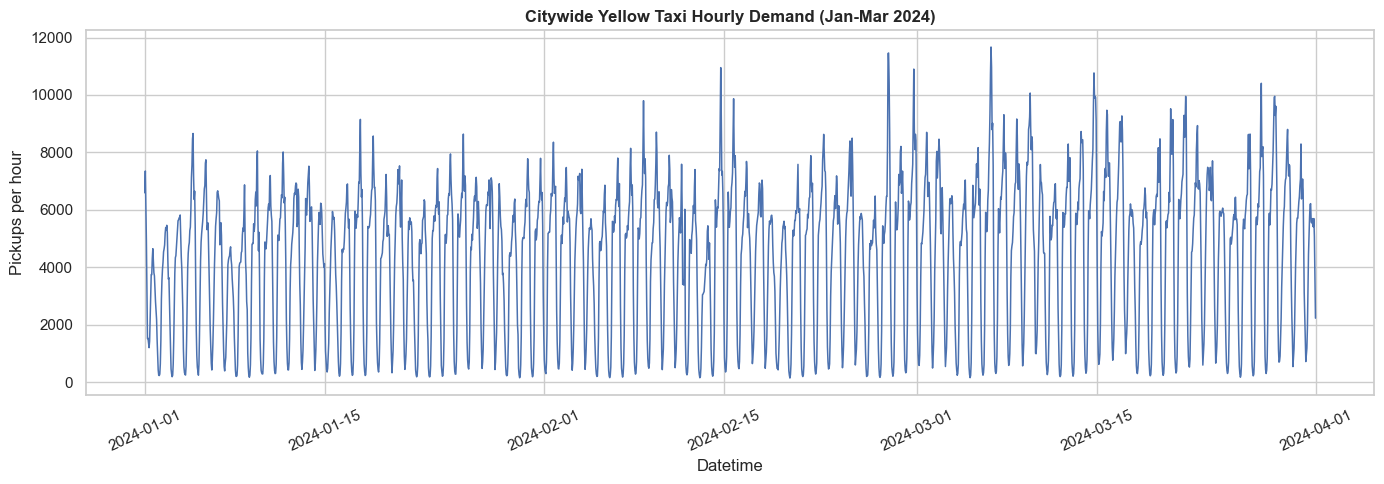

In [39]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.lineplot(data=citywide_hourly, x='tpep_pickup_datetime', y='demand', ax=ax, linewidth=1.1)
ax.set_title('Citywide Yellow Taxi Hourly Demand (Jan-Mar 2024)')
ax.set_xlabel('Datetime')
ax.set_ylabel('Pickups per hour')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


Interpretation:
- Clear repeating peaks and dips indicate strong temporal patterns.
- This suggests lag and calendar features will likely help forecasting.


### 1.2 Average demand by hour of day

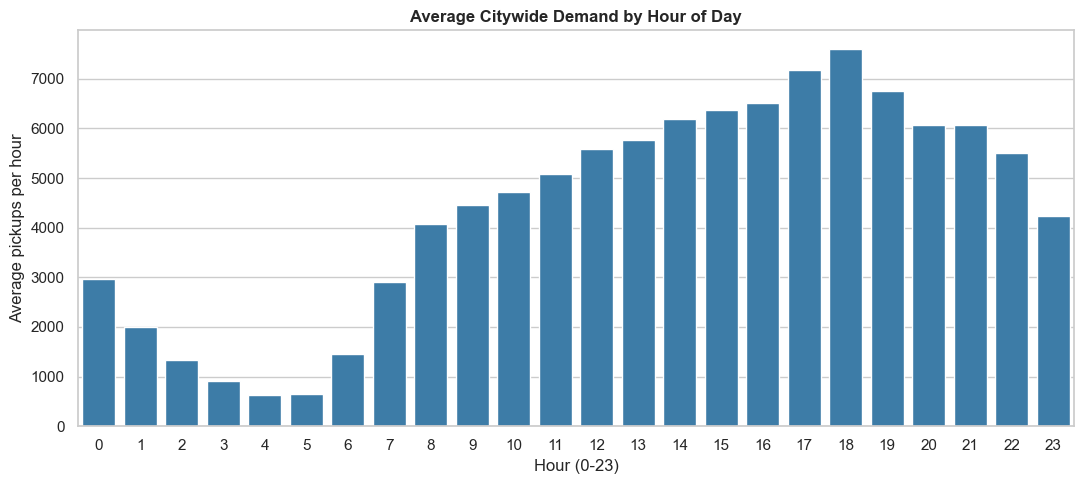

In [40]:
hour_profile = (
    citywide_hourly.assign(hour=citywide_hourly['tpep_pickup_datetime'].dt.hour)
    .groupby('hour', as_index=False)['demand']
    .mean()
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=hour_profile, x='hour', y='demand', color='#2c7fb8', ax=ax)
ax.set_title('Average Citywide Demand by Hour of Day')
ax.set_xlabel('Hour (0-23)')
ax.set_ylabel('Average pickups per hour')
plt.tight_layout()
plt.show()


Interpretation:
- Demand is lower overnight and higher during daytime/evening.
- Hour-of-day is an important predictor for the next modeling step.


## 2. Data Processing Progress

### 2.1 Data sources and collection considered
- Primary source: NYC TLC Yellow Taxi trip records (Parquet) for Jan-Mar 2024.
- Supporting source: Taxi zone lookup CSV (zone metadata).
- Collection approach: direct download to `data/raw/`.


In [41]:
# Data file manifest
manifest = pd.DataFrame({
    'file': [f.name for f in FILES] + ['taxi_zone_lookup.csv'],
    'size_mb': [round(f.stat().st_size / 1e6, 2) for f in FILES] + [round((DATA_DIR / 'taxi_zone_lookup.csv').stat().st_size / 1e6, 2)],
})
manifest


,file,size_mb
0,yellow_tripdata_2024-01.parquet,49.96
1,yellow_tripdata_2024-02.parquet,50.35
2,yellow_tripdata_2024-03.parquet,60.08
3,taxi_zone_lookup.csv,0.01


### 2.2 Cleaning steps considered and applied
1. Keep only required columns (`tpep_pickup_datetime`, `PULocationID`).
2. Parse datetime and remove invalid timestamps.
3. Remove rows with missing pickup zone.
4. Keep only Jan-Mar 2024 records.
5. Remove invalid zone IDs (`PULocationID <= 0`).
6. Aggregate to hourly demand per zone.


In [42]:
# Simple cleaning audit for transparency
audit = {
    'raw_rows': int(len(raw_df)),
    'missing_or_invalid_datetime': int(pd.to_datetime(raw_df['tpep_pickup_datetime'], errors='coerce').isna().sum()),
    'missing_PULocationID': int(raw_df['PULocationID'].isna().sum()),
    'out_of_scope_datetime': int(((pd.to_datetime(raw_df['tpep_pickup_datetime'], errors='coerce') < pd.Timestamp('2024-01-01')) |
                                  (pd.to_datetime(raw_df['tpep_pickup_datetime'], errors='coerce') >= pd.Timestamp('2024-04-01'))).fillna(False).sum()),
    'invalid_PULocationID_le_0': int((raw_df['PULocationID'].fillna(-1) <= 0).sum())
}
pd.Series(audit)


raw_rows                       9554778
missing_or_invalid_datetime          0
missing_PULocationID                 0
out_of_scope_datetime               21
invalid_PULocationID_le_0            0
dtype: int64

### 2.3 Reasoning for processing decisions
- Filtering to Jan-Mar 2024 keeps the dataset consistent with project scope.
- Dropping invalid timestamps/zones avoids noisy or unusable records.
- Hourly aggregation matches the forecasting objective (one-hour-ahead demand).
- These are initial, reproducible processing steps and can be refined later.


## 3. Modeling Methods

### 3.1 Process being predicted
For each zone and hour, predict next-hour demand:
`target_demand_next_hour = demand at t+1`.

This supports short-horizon operational planning.


### 3.2 Preliminary features
- `lag_1h`: demand in previous hour (short-term persistence).
- `lag_24h`: demand same hour previous day (daily pattern).
- `hour`, `day_of_week`: basic calendar context.
- `PULocationID`: zone identity for spatial variation.


In [43]:
# Build a simple modeling table
panel = hourly.sort_values(['PULocationID', 'tpep_pickup_datetime']).copy()
grp = panel.groupby('PULocationID')['demand']

panel['lag_1h'] = grp.shift(1)
panel['lag_24h'] = grp.shift(24)
panel['hour'] = panel['tpep_pickup_datetime'].dt.hour
panel['day_of_week'] = panel['tpep_pickup_datetime'].dt.dayofweek
panel['target_demand_next_hour'] = grp.shift(-1)

model_df = panel.dropna().reset_index(drop=True)
print('Model table shape:', model_df.shape)
model_df[['PULocationID', 'tpep_pickup_datetime', 'demand', 'lag_1h', 'lag_24h', 'hour', 'day_of_week', 'target_demand_next_hour']].head(10)


Model table shape: (234764, 8)


,PULocationID,tpep_pickup_datetime,demand,lag_1h,lag_24h,hour,day_of_week,target_demand_next_hour
0,1,2024-01-03 16:00:00,1,2.0,1.0,16,2,4.0
1,1,2024-01-03 18:00:00,4,1.0,4.0,18,2,1.0
2,1,2024-01-04 11:00:00,1,4.0,3.0,11,3,2.0
3,1,2024-01-04 12:00:00,2,1.0,6.0,12,3,2.0
4,1,2024-01-04 14:00:00,2,2.0,2.0,14,3,2.0
5,1,2024-01-04 16:00:00,2,2.0,1.0,16,3,2.0
6,1,2024-01-04 17:00:00,2,2.0,4.0,17,3,1.0
7,1,2024-01-04 19:00:00,1,2.0,1.0,19,3,1.0
8,1,2024-01-05 03:00:00,1,1.0,1.0,3,4,1.0
9,1,2024-01-05 09:00:00,1,1.0,3.0,9,4,1.0


### 3.3 Why these features
- `lag_1h` and `lag_24h` are standard baseline time-series predictors.
- Hour/day features capture daily and weekly behavior seen in visualizations.
- Zone ID keeps the model from treating all locations as identical.
- This is intentionally simple for first check-in; richer features come later.


## 4. Preliminary Results & Interpretation

In [44]:
# Time-based split and baseline results (no complex model yet)
def smape(y_true, y_pred):
    denom = (y_true.abs() + y_pred.abs()).replace(0, 1e-8)
    return float((2 * (y_true - y_pred).abs() / denom).mean() * 100)

def wape(y_true, y_pred):
    denom = y_true.abs().sum()
    if denom == 0:
        return float('nan')
    return float((y_true - y_pred).abs().sum() / denom * 100)

q1 = model_df['tpep_pickup_datetime'].quantile(0.70)
q2 = model_df['tpep_pickup_datetime'].quantile(0.85)

val = model_df[(model_df['tpep_pickup_datetime'] > q1) & (model_df['tpep_pickup_datetime'] <= q2)].copy()
test = model_df[model_df['tpep_pickup_datetime'] > q2].copy()

val_preds = {
    'naive_lag1': val['lag_1h'],
    'seasonal_lag24': val['lag_24h'],
}
test_preds = {
    'naive_lag1': test['lag_1h'],
    'seasonal_lag24': test['lag_24h'],
}

def evaluate(split_name, y, pred_dict):
    rows = []
    for name, p in pred_dict.items():
        rows.append({
            'split': split_name,
            'model': name,
            'MAE': (y - p).abs().mean(),
            'RMSE': (((y - p) ** 2).mean()) ** 0.5,
            'sMAPE_%': smape(y, p),
            'WAPE_%': wape(y, p)
        })
    return rows

results = pd.DataFrame(
    evaluate('validation', val['target_demand_next_hour'], val_preds) +
    evaluate('test', test['target_demand_next_hour'], test_preds)
).round(3)

results


,split,model,MAE,RMSE,sMAPE_%,WAPE_%
0,validation,naive_lag1,15.809,37.262,50.526,38.407
1,validation,seasonal_lag24,16.588,40.694,51.957,40.299
2,test,naive_lag1,16.318,38.286,52.562,40.930
3,test,seasonal_lag24,14.530,34.844,51.618,36.445


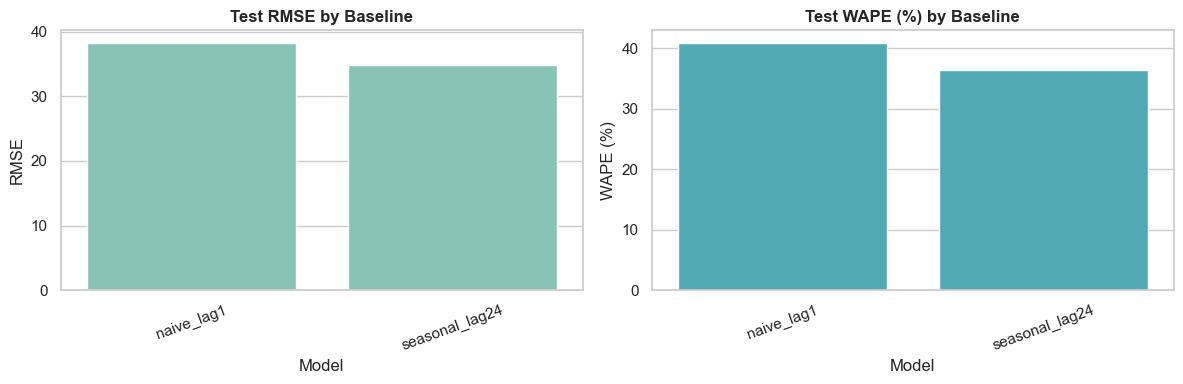

In [45]:
# Visual comparison on test split
test_res = results[results['split'] == 'test']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=test_res, x='model', y='RMSE', ax=axes[0], color='#7fcdbb')
axes[0].set_title('Test RMSE by Baseline')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('RMSE')

sns.barplot(data=test_res, x='model', y='WAPE_%', ax=axes[1], color='#41b6c4')
axes[1].set_title('Test WAPE (%) by Baseline')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('WAPE (%)')

for ax in axes:
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


Interpretation:
- Preliminary baselines provide a useful starting point, not final performance.
- If `lag_1h` outperforms `lag_24h`, short-term persistence dominates in this window.
- If errors remain high, likely reasons are missing external drivers (weather/events), sparse low-demand zone-hours, and model simplicity.

What this means for next check-in:
- Add richer features (weather, holidays, rolling stats).
- Compare simple baselines against stronger ML models.
- Report zone-specific error behavior.
